Learning Curves Sample
In this notebook, we will explore how to plot learning curves for a PyTorch neural network model. Learning curves are a useful tool for diagnosing the performance of a model and understanding how it learns over time.

For this example, we will use a simple feedforward neural network trained on the Flight Price Prediction dataset, which can be found on Kaggle link.

This is a regression problem, where the goal is to predict the price of a flight based on various features such as airline, departure time, arrival time, etc.

In [21]:
import math

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

## EDA
Let's start by loading and understanding the dataset. For simplicity, the data will be loaded into a Pandas DataFrame during this and the preprocessing phase. Once we are ready to start training the model, it will be converted into PyTorch tensors.

In [23]:
path = kagglehub.dataset_download("shubhambathwal/flight-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\mario\.cache\kagglehub\datasets\shubhambathwal\flight-price-prediction\versions\2


In [24]:
data = pd.read_csv(f"{path}/Clean_Dataset.csv")

data

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


<Axes: xlabel='price', ylabel='Count'>

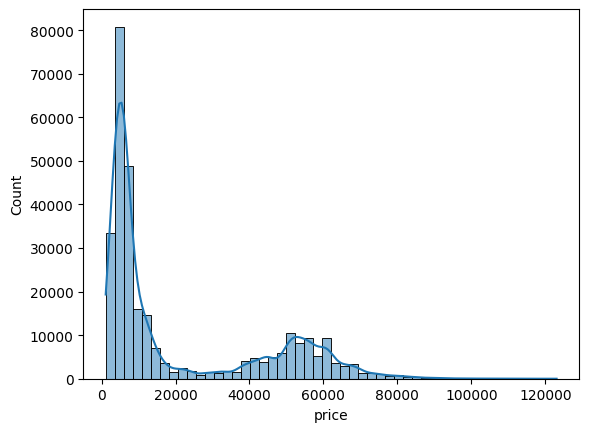

In [25]:
sns.histplot(data["price"], bins=50, kde=True)

In [26]:
numerical_cols = ["duration", "days_left"]

data[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,300153.0,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,26.004751,13.561004,1.00,15.00,26.00,38.00,49.00


In [27]:
categorical_cols = ["airline", "flight", "source_city", "destination_city", "class", "departure_time", "arrival_time",
                    "stops"]

data[categorical_cols].describe().T

,count,unique,top,freq
airline,300153,6,Vistara,127859
flight,300153,1561,UK-706,3235
source_city,300153,6,Delhi,61343
destination_city,300153,6,Mumbai,59097
class,300153,2,Economy,206666
departure_time,300153,6,Morning,71146
arrival_time,300153,6,Night,91538
stops,300153,3,one,250863


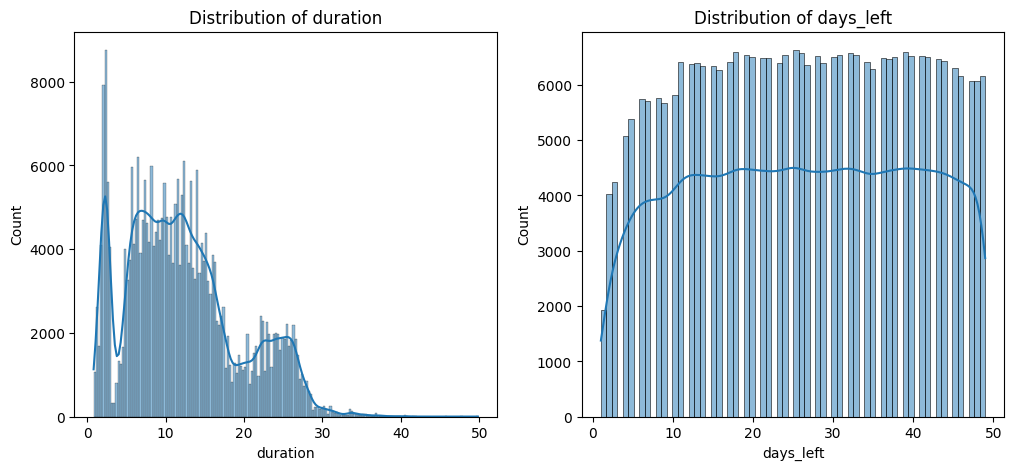

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

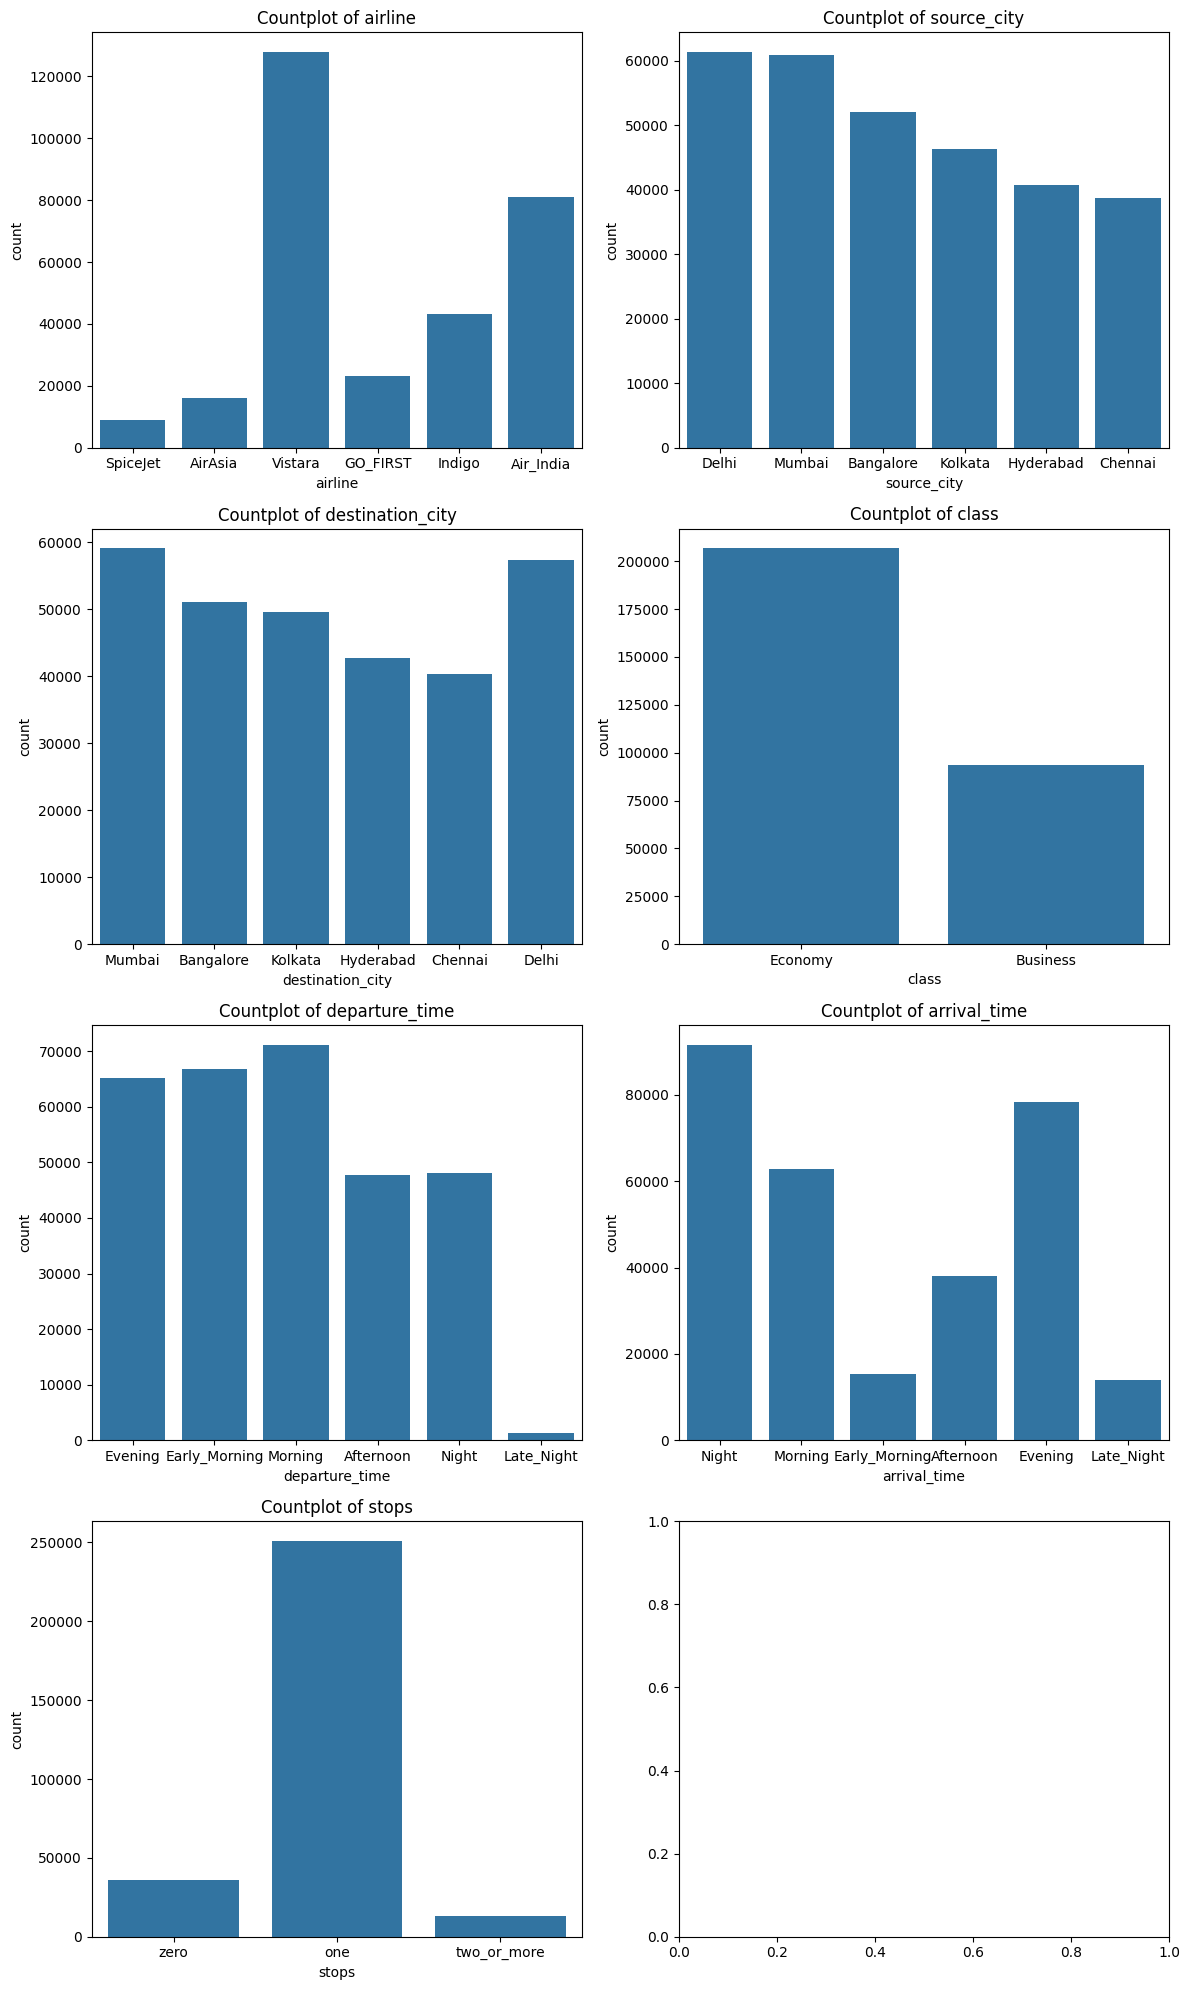

In [29]:
fig, axs = plt.subplots(4, 2, figsize=(12, 20))
cols = [c for c in categorical_cols if c != "flight"]

for ax, col in zip(axs.ravel(), cols):
    sns.countplot(data=data, x=col, ax=ax)
    ax.set_title(f'Countplot of {col}')

plt.tight_layout()

## Preprocessing
For this dataset, we will perform the following preprocessing steps:

**One-hot encode categorical features (airline, source_city, destination_city).**
- Apply standard scaling to numerical features (duration, days_left).
- Ordinal-encode ordinal features (departure_time, arrival_time, stops, class).
- Drop flight column; it has very high cardinality, and it is related to airline, source_city and destination_city features.
- For the target column, divide it by 100 to make the values more manageable for the model and for end user interpretability. 
Since the prices are expressed in Indian Rupees, this will roughly convert the prices to USD, which is more familiar to a wider audience.

In [30]:
x_train, x_test, y_train, y_testval = train_test_split(
    data.drop(columns=["price", "flight"]),
    data["price"],
    test_size=0.3,
    random_state=42,
)

x_test, x_val, y_test, y_val = train_test_split(
    x_test,
    y_testval,
    test_size=0.5,
    random_state=42,
)

In [31]:
airline_categories = list(data['airline'].unique())
city_categories = list(set(data['source_city'].unique()).union(set(data['destination_city'].unique())))

stops_categories = ["zero", "one", "two_or_more"]
class_categories = ["Economy", "Business"]
flight_time_categories = ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]

In [32]:
preprocessing = make_pipeline(
    ColumnTransformer(
        transformers=[
            (
                "onehot",
                OneHotEncoder(categories=[airline_categories, city_categories, city_categories], drop="first"),
                ["airline", "source_city", "destination_city"],
            ),
            (
                "ordinal",
                OrdinalEncoder(
                    categories=[
                        flight_time_categories,
                        flight_time_categories,
                        stops_categories,
                        class_categories
                    ]
                ),
                ["departure_time", "arrival_time", "stops", "class"],
            ),
            (
                "scaler",
                StandardScaler(),
                ["duration", "days_left"],
            ),
        ]
    ))

In [33]:
x_train_preprocessed = preprocessing.fit_transform(x_train)
x_val_preprocessed = preprocessing.transform(x_val)
x_test_preprocessed = preprocessing.transform(x_test)

y_train_preprocessed = y_train / 100
y_val_preprocessed = y_val / 100
y_test_preprocessed = y_test / 100

In [34]:
class FlightPriceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float32).view(-1, 1).to(device)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [35]:
train_data = FlightPriceDataset(x_train_preprocessed, y_train_preprocessed)
val_data = FlightPriceDataset(x_val_preprocessed, y_val_preprocessed)
test_data = FlightPriceDataset(x_test_preprocessed, y_test_preprocessed)

## Training Loop with Learning Curves
Let's start by creating our train function. It will handle training and will evaluate loss on the validation set at the end of each epoch.

In [36]:
from tqdm import tqdm
import torch

def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _device):
    # Inicializamos las listas para guardar el historial
    train_loss_history = []
    val_loss_history = []

    for epoch in range(_num_epochs):
        # --- FASE DE ENTRENAMIENTO ---
        _model.train()
        running_loss = 0.0
        
        for X_batch, y_batch in tqdm(_train_loader, desc=f"Epoch {epoch + 1}/{_num_epochs}"):
            
            X_batch, y_batch = X_batch.to(_device), y_batch.to(_device)
            
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            
            running_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_loss / len(_train_loader.dataset)
        train_loss_history.append(epoch_train_loss)

        # --- FASE DE VALIDACIÓN ---
        _model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                X_val, y_val = X_val.to(_device), y_val.to(_device)
                
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)

        epoch_val_loss = val_loss / len(_val_loader.dataset)
        val_loss_history.append(epoch_val_loss)
        
        print(f"Epoch {epoch+1} loss: {epoch_train_loss:.2f} (train) | {epoch_val_loss:.2f} (val)")

    # Regresamos el historial completo para poder graficar
    return train_loss_history, val_loss_history

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


train_subset = Subset(train_data, indices=range(500))

# Definimos la arquitectura del modelo
model = nn.Sequential(
    nn.Linear(train_data.X.shape[1], 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
batch_size = 64


train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)

Usando dispositivo: cpu


In [ ]:
# Ejecutamos la función y guardamos las pérdidas
train_losses, val_losses = train(
    _model=model, 
    _train_loader=train_loader, 
    _val_loader=val_loader, 
    _criterion=criterion, 
    _optimizer=optimizer, 
    _num_epochs=num_epochs,
    _device=device 
)

Epoch 1/50: 100%|██████████| 8/8 [00:00<00:00, 102.51it/s]


Epoch 1 loss: 98488.71 (train) | 92318.56 (val)


Epoch 2/50: 100%|██████████| 8/8 [00:00<00:00, 216.85it/s]


Epoch 2 loss: 94509.30 (train) | 84905.99 (val)


Epoch 3/50: 100%|██████████| 8/8 [00:00<00:00, 200.16it/s]


...

Epoch 48 loss: 2157.29 (train) | 3323.36 (val)


Epoch 49/50: 100%|██████████| 8/8 [00:00<00:00, 131.75it/s]


Epoch 49 loss: 1902.59 (train) | 3176.40 (val)


Epoch 50/50: 100%|██████████| 8/8 [00:00<00:00, 131.48it/s]


Epoch 50 loss: 1809.08 (train) | 3070.01 (val)


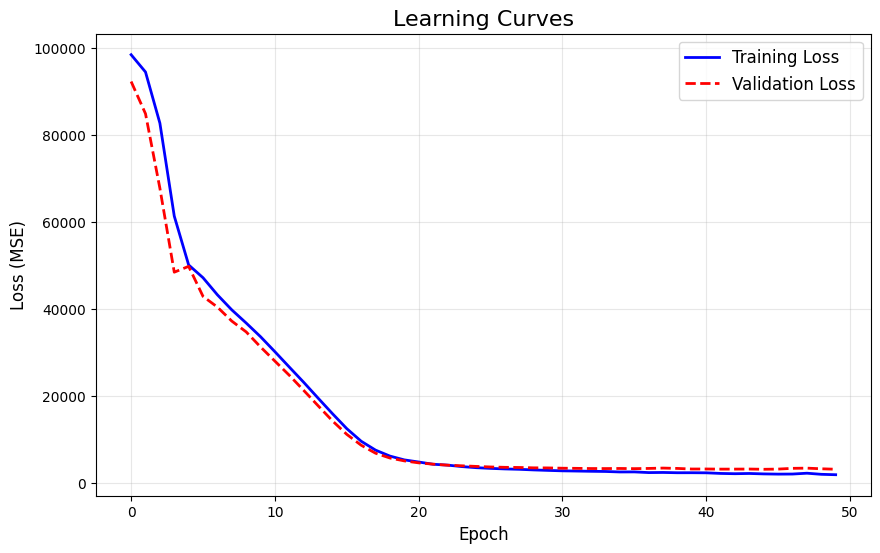

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss', color='blue', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--')
    
    plt.title('Learning Curves', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    
    
    plt.show()

# Llamamos a la función con nuestros resultados
plot_learning_curves(train_losses, val_losses)

In [40]:
def plot_learning_curves(_train_losses, _val_losses):
    pass

In [41]:
plot_learning_curves(train_losses, val_losses)

## Final Evaluation
Finally, we will evaluate the model on the test set to see how it performs on unseen data.

In [42]:
test_loader = DataLoader(test_data, batch_size=batch_size)

test_loss_batch = 0.0
with torch.no_grad():
    for X_val, y_test in test_loader:
        test_outputs = model(X_val)
        test_loss_batch += criterion(test_outputs, y_test).item() * X_val.size(0)

test_loss = test_loss_batch / len(test_loader.dataset)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(
    f"A prediction made by this model will be off by roughly {math.sqrt(test_loss) * 100:.2f} Rupees (about {math.sqrt(test_loss):.2f} USD) from the actual price on average.")

Test Loss (MSE): 3186.9648
A prediction made by this model will be off by roughly 5645.32 Rupees (about 56.45 USD) from the actual price on average.


## Nueva configuracion con modificaciones

In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Reducción de complejidad y aplicación de Dropout
# p=0.3 significa que en cada paso, el 30% de las neuronas de esa capa se apagan.
model_regularized = nn.Sequential(
    nn.Linear(train_data.X.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),  # Aplicamos Dropout después de la activación
    
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(p=0.2),  # Un poco menos de dropout en la última capa oculta
    
    nn.Linear(32, 1)
).to(device)

criterion = nn.MSELoss()


optimizer_regularized = optim.Adam(model_regularized.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 50
batch_size = 64



train_losses_reg, val_losses_reg = train(
    _model=model_regularized, 
    _train_loader=train_loader, 
    _val_loader=val_loader, 
    _criterion=criterion, 
    _optimizer=optimizer_regularized, 
    _num_epochs=num_epochs,
    _device=device
)

# Graficamos nuevamente
plot_learning_curves(train_losses_reg, val_losses_reg)

Epoch 1/50: 100%|██████████| 8/8 [00:00<00:00, 180.11it/s]


Epoch 1 loss: 99033.17 (train) | 94130.33 (val)


Epoch 2/50: 100%|██████████| 8/8 [00:00<00:00, 181.09it/s]


Epoch 2 loss: 98823.34 (train) | 93813.38 (val)


Epoch 3/50: 100%|██████████| 8/8 [00:00<00:00, 151.29it/s]


...

Epoch 48 loss: 8090.80 (train) | 5464.21 (val)


Epoch 49/50: 100%|██████████| 8/8 [00:00<00:00, 221.22it/s]


Epoch 49 loss: 8755.09 (train) | 5260.46 (val)


Epoch 50/50: 100%|██████████| 8/8 [00:00<00:00, 221.29it/s]


Epoch 50 loss: 8136.37 (train) | 5078.40 (val)


In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(train_losses, val_losses, title="Curvas de Aprendizaje"):
   
   
    plt.figure(figsize=(10, 6))
    
    
    plt.plot(train_losses, label='Entrenamiento (Train Loss)', color='blue', linewidth=2)
    
   
    plt.plot(val_losses, label='Validación (Val Loss)', color='orange', linewidth=2, linestyle='--')
    
   
    plt.title(title, fontsize=16)
    plt.xlabel('Épocas (Epochs)', fontsize=12)
    plt.ylabel('Pérdida (MSE)', fontsize=12)
    
    
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    
    plt.tight_layout()
    plt.show()

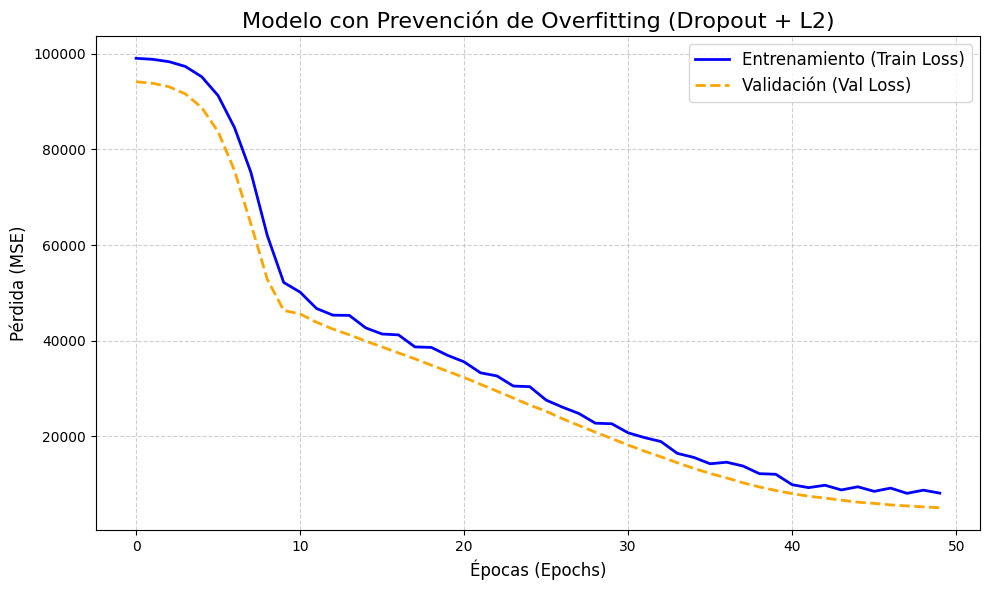

In [46]:
# Generar la gráfica del modelo con regularización
plot_learning_curves(
    train_losses=train_losses_reg, 
    val_losses=val_losses_reg, 
    title="Modelo con Prevención de Overfitting (Dropout + L2)"
)

## Reflexion sobre las 2 versiones

### El modelo original
En la gráfica del modelo original observamos el clásico comportamiento de una red con exceso de capacidad. Al tener capas tan densas (512, 256 neuronas) sin ninguna restricción, el modelo actuó como una base de datos gigante.

- Lógicamente: La red tenía tantas conexiones disponibles que simplemente "memorizó" las respuestas de tu conjunto de entrenamiento. Por eso la curva de entrenamiento (azul) cae drásticamente casi a cero.

- El fallo: Al no verse forzada a buscar patrones subyacentes, cuando se topó con el conjunto de validación (datos que nunca había visto), falló rotundamente. La gran separación entre las dos curvas es la huella digital del overfitting (alta varianza).

### El modelo modificado

En la gráfica con la estructura modificada, vemos un comportamiento mucho más sano. Las curvas viajan mucho más juntas.
